dyngen(batch)绘制指标

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'

sns.set_style("whitegrid", rc={"grid.color": ".9", "axes.edgecolor": ".9",})

In [2]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/dyngen.pkl'
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)

clusters_path = '../clusters/dyngen.pkl'
with open(clusters_path, 'rb') as f:
    clusters = pkl.load(f)
cluster_edges

[('sA->sB', 'sB->sBmid'),
 ('sB->sBmid', 'sBmid->sD'),
 ('sB->sBmid', 'sBmid->sC'),
 ('sBmid->sD', 'sD->sEndD'),
 ('sBmid->sC', 'sC->sEndC')]

In [3]:
base_dir = '/home/nas3/biod/xueweizhi/velocity_benchmark_output/outputs'

In [4]:
save_dir = '../figures/dyngen/batch'
import os
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

In [5]:
data = 'dyngen/batch-dataset_modified'

In [6]:
models_total = ['scvelo', 'scvelo(avg)', 'unitvelo', 'velovae', 'deepvelo(cui)', 'latentvelo', 'latentvelo(lt)', 'velovi', 'topovelo', 'stt', 'stt(vj)', 'velovgi']

绘制CBDir

In [7]:
metric_name = 'cbdir'
basis = 'umap'
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']
results = {}
for cluster_edge in cluster_edges: 
    cluster = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        metric_file = f'{base_dir}/{data}/{model}/{metric_name}_{model_name}_velocity_{basis}.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        if cluster in metric.keys():
            if model == 'deepvelo_cui':
                model = 'deepvelo(cui)'
            result[model] = metric[cluster]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_vj_{basis}.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            if cluster in stt_metric.keys():
                result['stt(vj)'] = stt_metric[cluster]
        if model == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_spliced_velocity_{basis}.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            if cluster in ltv_metric.keys():
                result['latentvelo(lt)'] = ltv_metric[cluster]
    results[cluster] = result

In [8]:
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
edge_color_map = dict(zip(results.keys(), colors))

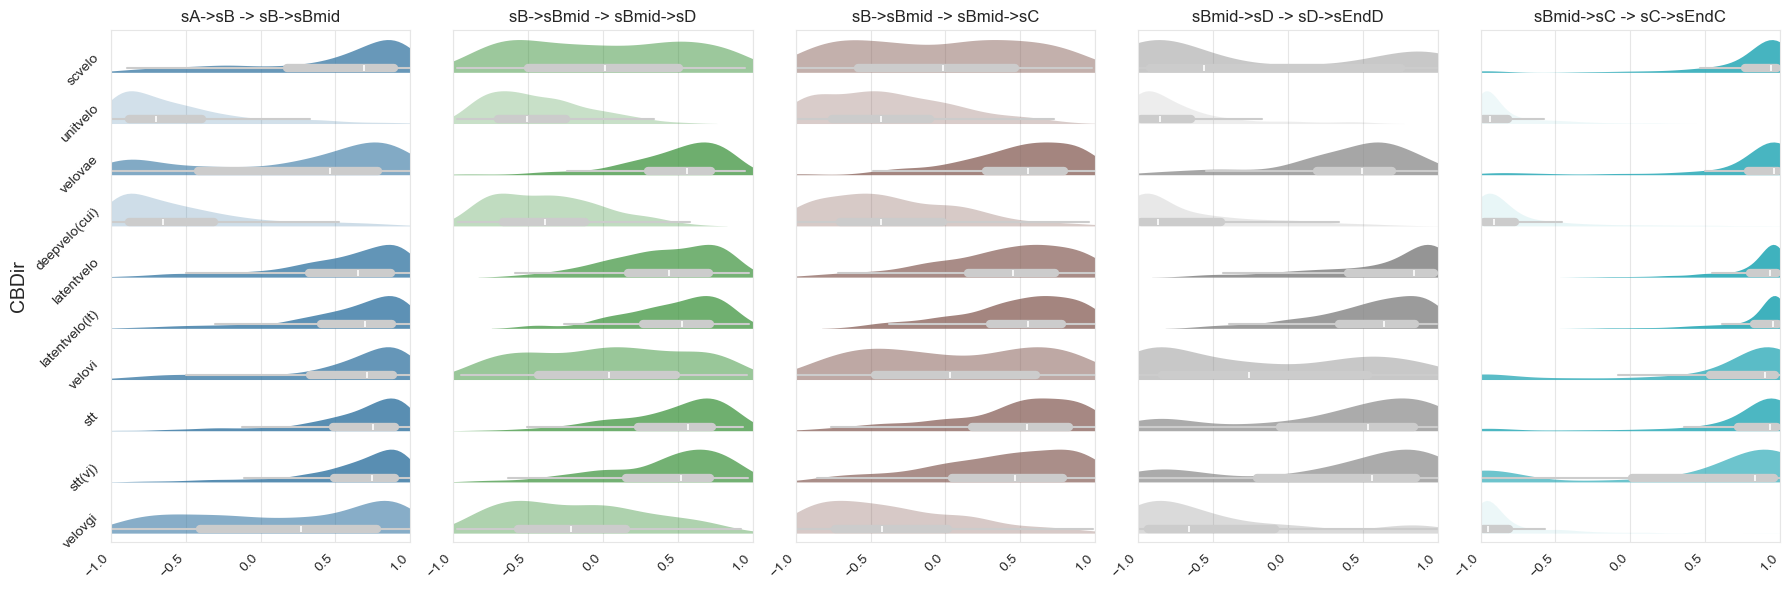

In [9]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(18, 6))
for i, (cluster, result) in enumerate(results.items()):
    df = pd.DataFrame([(model, value) for model, values in result.items() for value in values], columns=["model", metric_name])
    model_means = {model: np.mean(values) for model, values in result.items()}
    violins = sns.violinplot(
        data=df, 
        x=metric_name, 
        y='model', 
        orient='h', 
        color=edge_color_map[cluster], 
        split=True,
        width=0.8, 
        gap=0.2, 
        linewidth=0, 
        density_norm='count', 
        inner_kws=dict(box_width=6, whis_width=1.5, color=".8"), 
        ax=axs[i], 
    )
    for j, model in enumerate(result.keys()):
        violins.collections[j].set_alpha((model_means[model] + 1) / 2)
    axs[i].set_title(cluster)
    axs[i].set_xlim(-1, 1)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('CBDir', fontsize=14)
    for label in axs[i].get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    for label in axs[i].get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.svg')
plt.show()

绘制ICCoh

In [10]:
metric_name = 'inner_cluster_coh'
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']
results = {}
for cluster in clusters:
    result = {}
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        metric_file = f'{base_dir}/{data}/{model}/{metric_name}_{model_name}_velocity.pkl'
        with open(metric_file, 'rb') as f:
            metric = pkl.load(f)
        if model == 'deepvelo_cui':
            model = 'deepvelo(cui)'
        result[model] = metric[cluster]
        if model == 'stt':
            stt_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_vj.pkl'
            with open(stt_metric_file, 'rb') as f:
                stt_metric = pkl.load(f)
            result['stt(vj)'] = stt_metric[cluster]
        if model == 'latentvelo':
            ltv_metric_file = f'{base_dir}/{data}/{model}/{metric_name}_spliced_velocity.pkl'
            with open(ltv_metric_file, 'rb') as f:
                ltv_metric = pkl.load(f)
            result['latentvelo(lt)'] = ltv_metric[cluster]
    results[cluster] = result
results

{'sA->sB': {'scvelo': [0.8688607728588884,
   0.8862447834470663,
   0.8351458761577133,
   0.9016797958264278,
   0.9366282489149799,
   0.870877445478409,
   0.8821794439979238,
   0.8580509101535545,
   0.8449765767170069,
   0.8717471361897626,
   0.932200212275632,
   0.8693036585902961,
   0.8576352752266031,
   0.9023664977430682,
   0.9025663139718183,
   0.9133321479469303,
   0.8535379218787482,
   0.9346800361478079,
   0.8831096163030329,
   0.9165797819102114,
   0.8860600969269108,
   0.9227365989306485,
   0.9299903322379353,
   0.888007236117297,
   0.829720010387624,
   0.8751862039552242,
   0.8688612015426643,
   0.8608772406145119,
   0.8506803921859418,
   0.9048041719498051,
   0.9065830542881868,
   0.8636608780500374,
   0.8820908458460986,
   0.8876416784396464,
   0.9035891632614343,
   0.8830957824789227,
   0.8755189423112182,
   0.8884434136810601,
   0.8772813769698825,
   0.8588443005254088,
   0.8642101879921865,
   0.895818361099649,
   0.92926569498713

In [11]:
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
cluster_color_map = dict(zip(results.keys(), colors))

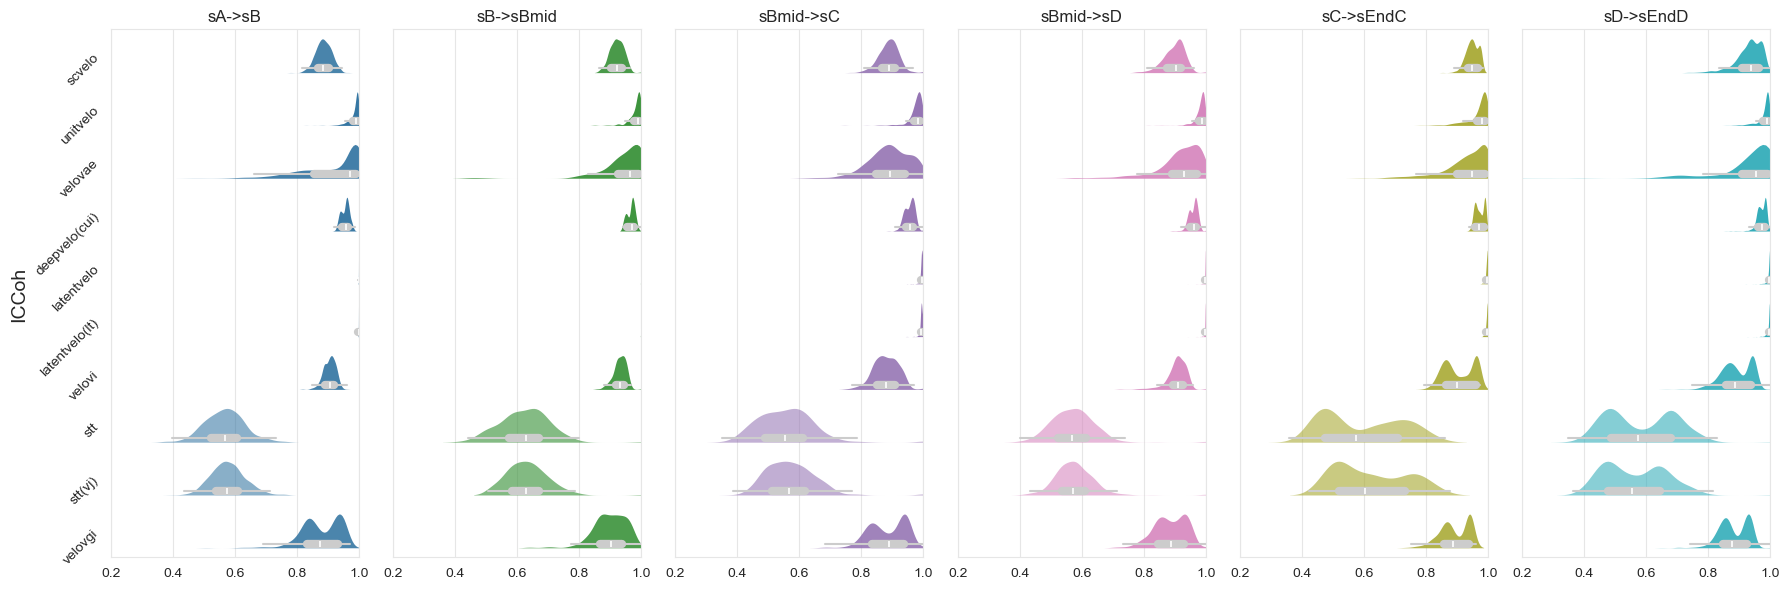

In [12]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(18, 6))
for i, (cluster, result) in enumerate(results.items()):
    df = pd.DataFrame([(model, value) for model, values in result.items() for value in values], columns=["model", metric_name])
    model_means = {model: np.mean(values) for model, values in result.items()}
    violins = sns.violinplot(
        data=df, 
        x=metric_name, 
        y='model', 
        orient='h', 
        color=cluster_color_map[cluster], 
        split=True, 
        width=0.8, 
        gap=0.2, 
        linewidth=0, 
        density_norm="count", 
        inner_kws=dict(box_width=6, whis_width=1.5, color=".8"),
        ax = axs[i], 
    )
    for j, model in enumerate(result.keys()):
        violins.collections[j].set_alpha(model_means[model])
    axs[i].set_title(cluster)
    axs[i].set_xlim(0.2, 1)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('ICCoh', fontsize=14)
    # for label in axs[i].get_xticklabels():
    #     label.set_rotation(45)
    #     label.set_ha('right')
    for label in axs[i].get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.svg')
plt.show()

绘制k-CBDir

In [13]:
import re
import ast

In [14]:
k = 5
basis = 'umap'
metric_name = 'gen_cbdir_edge'
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']
results = {}
for cluster_edge in cluster_edges:
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {'k': range(1, k+1)}
    for model in models: 
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        metric_file = f'{base_dir}/{data}/{model}/metric_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'{base_dir}/{data}/{model}/metric.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        idx_name = f'{metric_name}_{model_name}_velocity_{basis}_{edge}'
        if idx_name in metric.index:
            cbdir = metric.loc[metric.index == idx_name, '0'].values[0]
            if 'nan' not in cbdir:
                cbdir = re.sub(r'\s+', ', ', cbdir)
                cbdir = ast.literal_eval(cbdir)
                if model == 'deepvelo_cui':
                    model = 'deepvelo(cui)'
                result[model] = cbdir
        if model == 'stt': 
            stt_idx_name = f'{metric_name}_vj_{basis}_{edge}'
            if stt_idx_name in metric.index:
                cbdir = metric.loc[metric.index == stt_idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'\s+', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result['stt(vj)'] = cbdir
        if model == 'latentvelo':
            ltv_idx_name = f'{metric_name}_spliced_velocity_{basis}_{edge}'
            if ltv_idx_name in metric.index:
                cbdir = metric.loc[metric.index == ltv_idx_name, '0'].values[0]
                if 'nan' not in cbdir:
                    cbdir = re.sub(r'\s+', ', ', cbdir)
                    cbdir = ast.literal_eval(cbdir)
                    result['latentvelo(lt)'] = cbdir
    results[edge] = result
results

{'sA->sB -> sB->sBmid': {'k': range(1, 6),
  'scvelo': [0.47662745, 0.52096161, 0.6573752, 0.73690863, 0.75948385],
  'unitvelo': [-0.5634959, -0.55804803, -0.43395768, -0.33194939, -0.29618394],
  'velovae': [0.21282695, 0.2283593, 0.36082798, 0.44079471, 0.46417155],
  'deepvelo(cui)': [-0.51770558,
   -0.50698633,
   -0.3784,
   -0.27570258,
   -0.2405079],
  'latentvelo': [0.52633705, 0.52934517, 0.66686638, 0.7528292, 0.77764108],
  'latentvelo(lt)': [0.5732283,
   0.58075307,
   0.71587502,
   0.79491026,
   0.81710731],
  'velovi': [0.50928694, 0.52568541, 0.65974788, 0.7408864, 0.76255998],
  'stt': [0.6232658, 0.63876109, 0.77656965, 0.84990539, 0.86813894],
  'stt(vj)': [0.62689091, 0.64227285, 0.77843566, 0.84986674, 0.86848366],
  'velovgi': [0.17120197, 0.22007027, 0.37205878, 0.46861122, 0.49615423]},
 'sB->sBmid -> sBmid->sD': {'k': range(1, 6),
  'scvelo': [0.00604556, 0.41289117, 0.60089854, 0.64170461, 0.65375684],
  'unitvelo': [-0.44224484, -0.05918326, 0.24875999, 

In [15]:
colors = {
    'scvelo': plt.cm.Set2(0 / 8),
    'unitvelo': plt.cm.Set2(1 / 8),
    'velovi': plt.cm.Set2(2 / 8),
    'velovae': plt.cm.Set2(3 / 8),
    'stt': plt.cm.Set2(4 / 8),
    'stt(vj)': plt.cm.Set2(4 / 8),
    'topovelo(KNN)': plt.cm.Set2(6 / 8),
    'topovelo(Delaunay)': plt.cm.Set3(1 / 12),
    'velovae(prior)': plt.cm.Set3(7 / 12),
    'deepvelo(cui)': plt.cm.Set3(8 / 12),
    'latentvelo(prior)': plt.cm.Set3(10 / 12),
    'latentvelo': plt.cm.tab20b(12 / 20),
    'latentvelo(batch)': plt.cm.tab20b(15 / 20),
    'latentvelo(annot)': plt.cm.tab20c(12 / 20),
    'latentvelo(annot)(batch)': plt.cm.tab20c(15 / 20),
    'latentvelo(prior)(lt)': plt.cm.Set3(10 / 12),
    'latentvelo(lt)': plt.cm.tab20b(12 / 20),
    'latentvelo(batch)(lt)': plt.cm.tab20b(15 / 20),
    'latentvelo(annot)(lt)': plt.cm.tab20c(12 / 20),
    'latentvelo(annot)(batch)(lt)': plt.cm.tab20c(15 / 20),
    'velovgi': plt.cm.tab20c(0 / 20),
    'velovgi(batch)': plt.cm.tab20c(3 / 20),
}
line_styles = {
    'scvelo': (1, 0),  # '-' 实线
    'unitvelo': (1, 0),  # '-' 实线
    'velovi': (1, 0),  # '-' 实线
    'velovae': (1, 0),  # '-' 实线
    'stt': (1, 0),  # '-' 实线
    'stt(vj)': (4, 2),  # '--' 虚线
    'topovelo(KNN)': (1, 0),  # '-' 实线
    'topovelo(Delaunay)': (1, 0),  # '-' 实线
    'velovae(prior)': (1, 0),  # '-' 实线
    'deepvelo(cui)': (1, 0),  # '-' 实线
    'latentvelo(prior)': (1, 0),  # '-' 实线
    'latentvelo': (1, 0),  # '-' 实线
    'latentvelo(batch)': (1, 0),  # '-' 实线
    'latentvelo(annot)': (1, 0),  # '-' 实线
    'latentvelo(annot)(batch)': (1, 0),  # '-' 实线
    'latentvelo(prior)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(lt)': (4, 2),  # '--' 虚线
    'latentvelo(batch)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(annot)(lt)': (4, 2),  # '--' 虚线
    'latentvelo(annot)(batch)(lt)': (4, 2),  # '--' 虚线
    'velovgi': (1, 0),  # '-' 实线
    'velovgi(batch)': (1, 0),  # '-' 实线
}

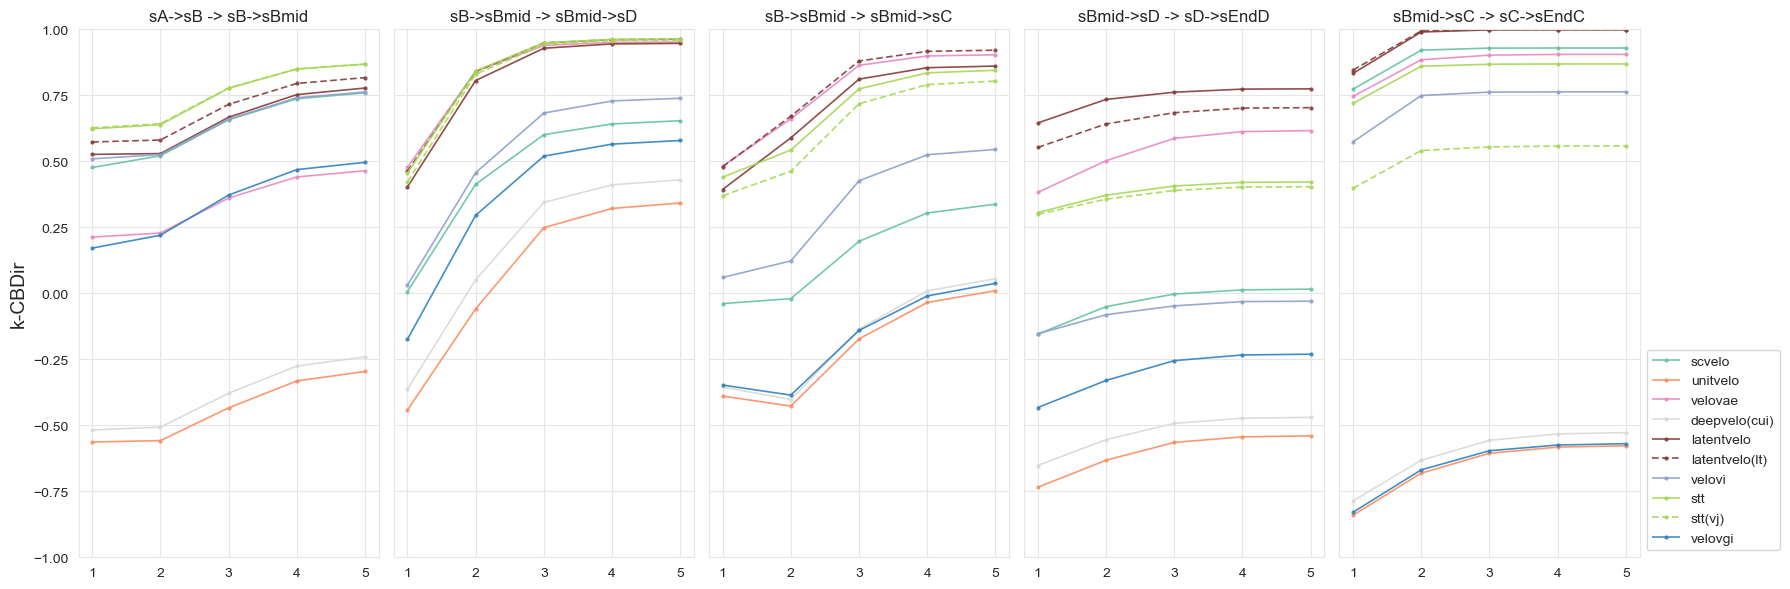

In [16]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(18, 6))
for i, (edge, result) in enumerate(results.items()):
    df = pd.DataFrame(result).melt(id_vars=['k'], var_name='model', value_name=metric_name)
    sns.lineplot(
        data=df, 
        x='k', 
        y=metric_name, 
        hue='model', 
        palette=colors,
        style='model',
        dashes=line_styles, 
        ax=axs[i], 
        linewidth=1.2,
        alpha=0.9,
        markersize=3,
        marker='o',
        markeredgewidth=0,
    )
    axs[i].set_title(edge)
    axs[i].set_xlabel('')
    axs[i].set_ylabel('k-CBDir', fontsize=14)
    axs[i].set_ylim(-1, 1)
    axs[i].get_legend().remove()

handles, labels = axs[0].get_legend_handles_labels()
plt.legend(handles, labels, loc='lower left', bbox_to_anchor=(1, 0))

plt.tight_layout()
plt.savefig(f'{save_dir}/{metric_name}.svg', bbox_inches='tight')
plt.show()

Time Corr & Velocity Acc

In [17]:
metrics = ['time_corr_spearman', 'velocity_acc']
models = ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'velovi', 'stt', 'velovgi']
results = {}
for metric_name in metrics:
    result = {}
    for model in models: 
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        metric_file = f'{base_dir}/{data}/{model}/metric_redo.csv'
        if not os.path.exists(metric_file):
            metric_file = f'{base_dir}/{data}/{model}/metric.csv'
        metric = pd.read_csv(metric_file, index_col=0)
        if metric_name == 'time_corr_spearman':
            if model in ['scvelo', 'unitvelo', 'velovae', 'deepvelo_cui', 'latentvelo', 'topovelo']:
                idx_name = f'{metric_name}_pred_t'
                t_corr = float(metric.loc[metric.index == idx_name, '0'].values[0])
                if model == 'deepvelo_cui':
                    model = 'deepvelo(cui)'
                result[model] = t_corr
            if model in ['scvelo', 'velovi', 'velovgi']:
                idx_name = f'{metric_name}_fit_t'
                t_corr = float(metric.loc[metric.index == idx_name, '0'].values[0])
                result[f'{model}(avg)' if model == 'scvelo' else model] = t_corr
        if metric_name == 'velocity_acc':
            idx_name = f'{metric_name}_{model_name}_velocity'
            v_acc = float(metric.loc[metric.index == idx_name, '0'].values[0])
            if model == 'deepvelo_cui':
                model = 'deepvelo(cui)'
            result[model] = v_acc
            if model == 'latentvelo':
                ltv_idx_name = f'{metric_name}_latent_velocity'
                v_acc = float(metric.loc[metric.index == ltv_idx_name, '0'].values[0])
                result['latentvelo(lt)'] = v_acc
    results[metric_name] = result
results

{'time_corr_spearman': {'scvelo': 0.42145680165528415,
  'scvelo(avg)': 0.4536725729848848,
  'unitvelo': -0.6236578523281053,
  'velovae': 0.14735820621059373,
  'deepvelo(cui)': 0.3873238488683121,
  'latentvelo': 0.8718521805056337,
  'velovi': 0.5108104300362147,
  'velovgi': 0.42441860915551394},
 'velocity_acc': {'scvelo': 0.02146643709307925,
  'unitvelo': -0.020487310357680394,
  'velovae': 0.02793889756059619,
  'deepvelo(cui)': 0.006438815253666297,
  'latentvelo': 0.03853451752908507,
  'latentvelo(lt)': 0.3033080127388721,
  'velovi': 0.01716772161244945,
  'stt': 0.0232674611050682,
  'velovgi': 0.002636964157825691}}

In [18]:
color_maps = [plt.cm.Blues, plt.cm.Greens]

In [19]:
models_total.remove('topovelo')

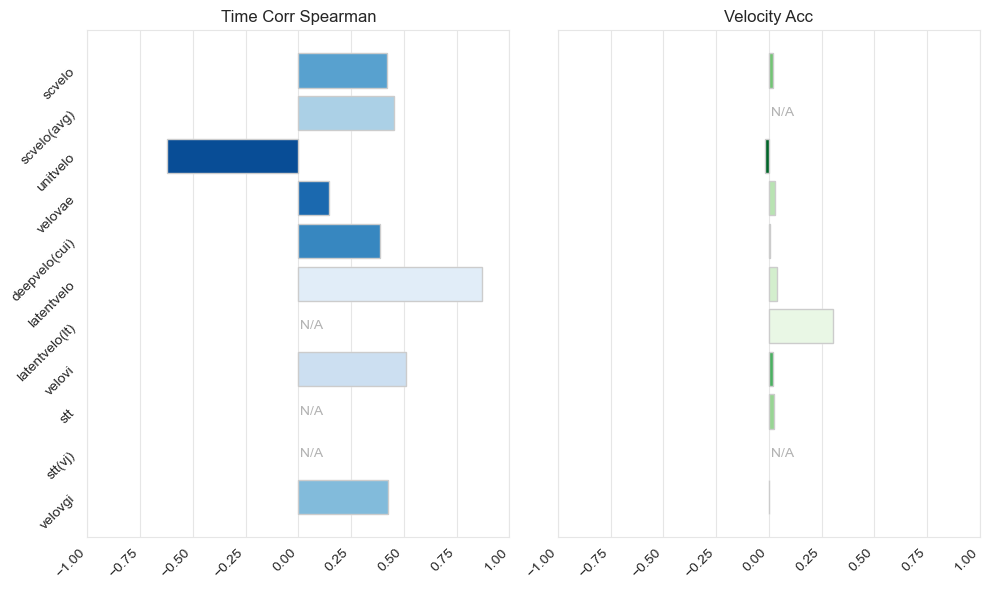

In [26]:
fig, axs = plt.subplots(nrows=1, ncols=len(results), sharex=True, sharey=True, figsize=(10, 6))
for i, (metric_name, result) in enumerate(results.items()):
    result_sorted = {model: result.get(model, float('nan')) for model in models_total}
    df = pd.DataFrame(list(result_sorted.items()), columns=['model', metric_name])
    color_map = color_maps[i]
    sns.barplot(data=df, x=metric_name, y='model', ax=axs[i], orient='h')
    df['rank'] = df[metric_name].rank(ascending=False)
    for j, (model, value, rank) in enumerate(zip(df['model'], df[metric_name], df['rank'])):
        if pd.isna(value):
            axs[i].text(x=0.01, y=j, s='N/A', ha='left', va='center', fontsize=10, color='.7')
        else:
            axs[i].barh(model, value, color=color_map(rank / (len(result) + 1)), edgecolor='.8', linewidth=1)
    axs[i].set_title(metric_name.replace('_', ' ').title())
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_xlim(-1, 1)
    for label in axs[i].get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    for label in axs[i].get_yticklabels():
        label.set_rotation(45)
        label.set_ha('right')
plt.tight_layout()
plt.savefig(f'{save_dir}/{"_".join(results.keys())}.svg', bbox_inches='tight')
plt.show()